# Customer Churn Prediction - Exploratory Data Analysis

This notebook explores the IBM Telco Customer Churn dataset to understand the data, identify patterns, and inform feature engineering decisions.

**Key questions this EDA answers:**
- How imbalanced is the target variable?
- Which features have the strongest relationship with churn?
- Are there data quality issues to address before modeling?
- What business insights emerge from the raw data?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {'no_churn': '#2563eb', 'churn': '#dc2626', 'neutral': '#64748b'}

## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nehamalik10/customer-churn-datset/Telco-Customer-Churn.csv')

# TotalCharges contains blank strings for 11 customers with 0 tenure.
# Convert to numeric (blanks become NaN), then fill with 0.0
# since these customers haven't been billed yet.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Convert SeniorCitizen from 0/1 to Yes/No for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nColumn types:\n{df.dtypes.value_counts()}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nTarget distribution:\n{df["Churn"].value_counts(normalize=True)}')

Shape: 7043 rows, 21 columns

Column types:
object     18
float64     2
int64       1
Name: count, dtype: int64

Missing values: 0

Target distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [5]:
# Verify: 0-tenure customers should have 0 TotalCharges after our fix
zero_tenure = df[df['tenure'] == 0]
print(f'Customers with 0 tenure: {len(zero_tenure)}')
print(f'Their TotalCharges values:\n{zero_tenure["TotalCharges"].value_counts()}')

Customers with 0 tenure: 11
Their TotalCharges values:
TotalCharges
0.0    11
Name: count, dtype: int64


## 2. Target Variable: Class Balance

With ~73% non-churn and ~27% churn, this is a meaningful imbalance -- not extreme, but enough that accuracy alone would be misleading as a metric.

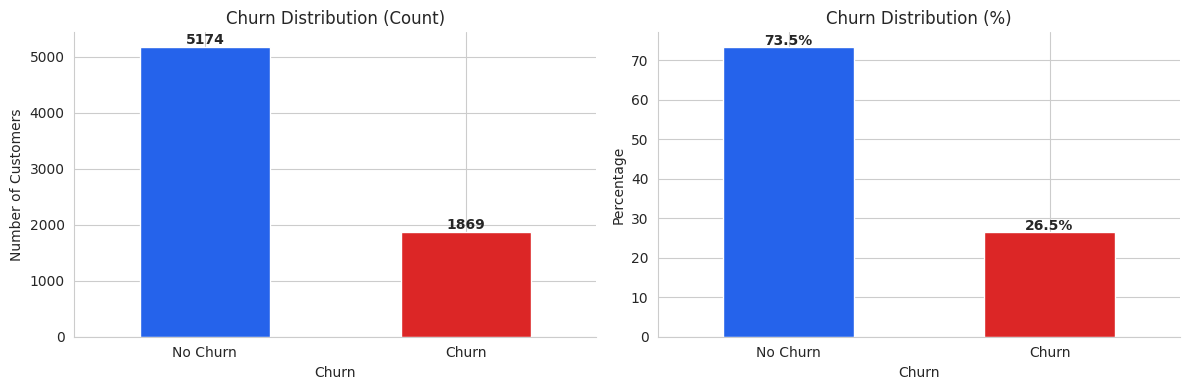

Churn rate: 26.5%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Churn'].value_counts()
colors = [COLORS['no_churn'], COLORS['churn']]
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

pcts = df['Churn'].value_counts(normalize=True) * 100
pcts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Churn Distribution (%)')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(['No Churn', 'Churn'], rotation=0)
for i, v in enumerate(pcts):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Churn rate: {(df["Churn"] == "Yes").mean():.1%}')

## 3. Churn Rate by Key Features

We examine churn rate across the features most likely to matter based on domain knowledge: contract type, internet service, payment method, and support services.

In [7]:
def plot_churn_rate_by_feature(df, feature):
    """Bar plot showing churn rate for each category of a feature."""
    churn_rate = df.groupby(feature)['Churn'].apply(
        lambda x: (x == 'Yes').mean()
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    churn_rate.plot(kind='bar', ax=ax, color=COLORS['churn'],
                    edgecolor='white', alpha=0.85)
    ax.set_title(f'Churn Rate by {feature}')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, min(1.0, churn_rate.max() * 1.3))
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(churn_rate):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

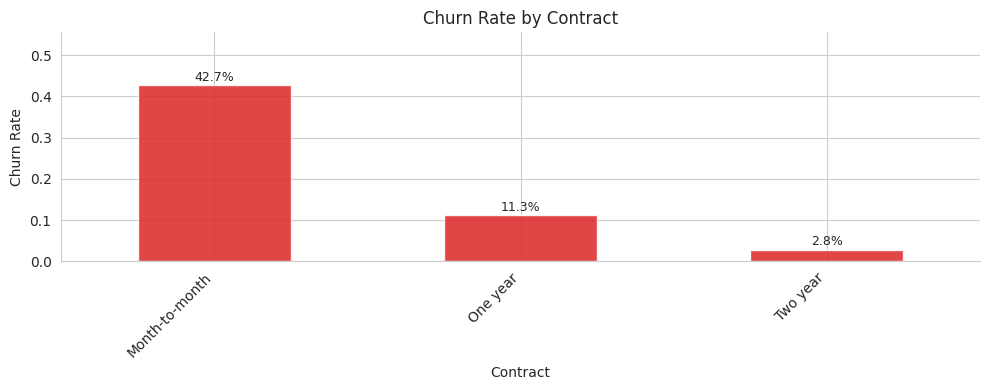

In [8]:
plot_churn_rate_by_feature(df, 'Contract')

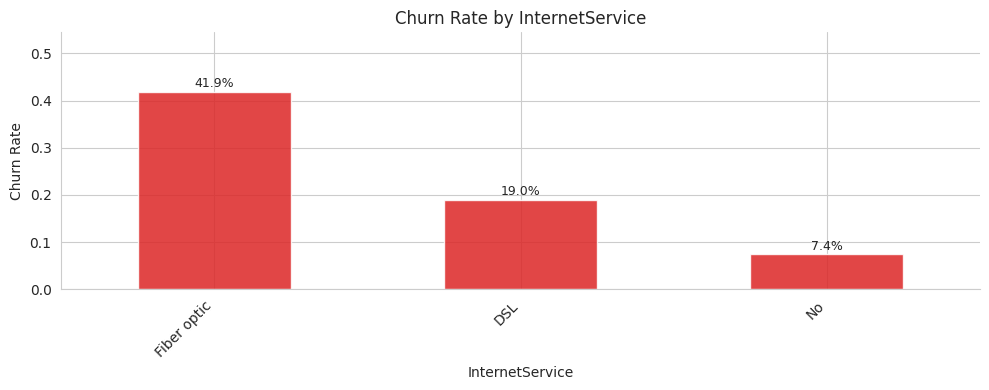

In [9]:
plot_churn_rate_by_feature(df, 'InternetService')

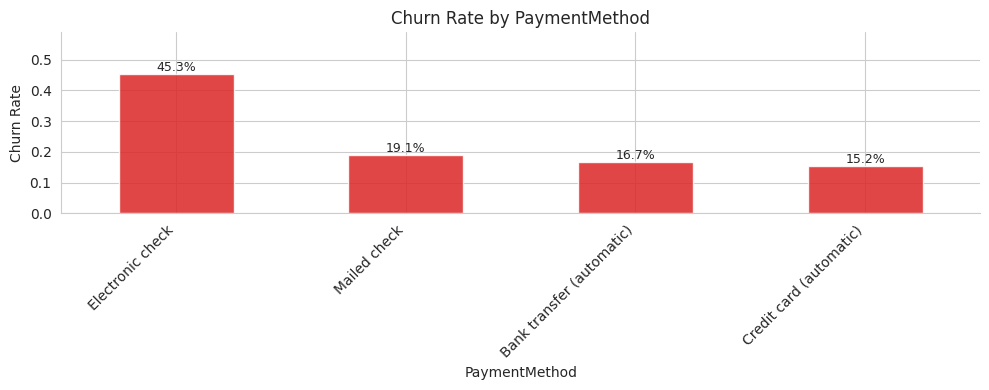

In [10]:
plot_churn_rate_by_feature(df, 'PaymentMethod')

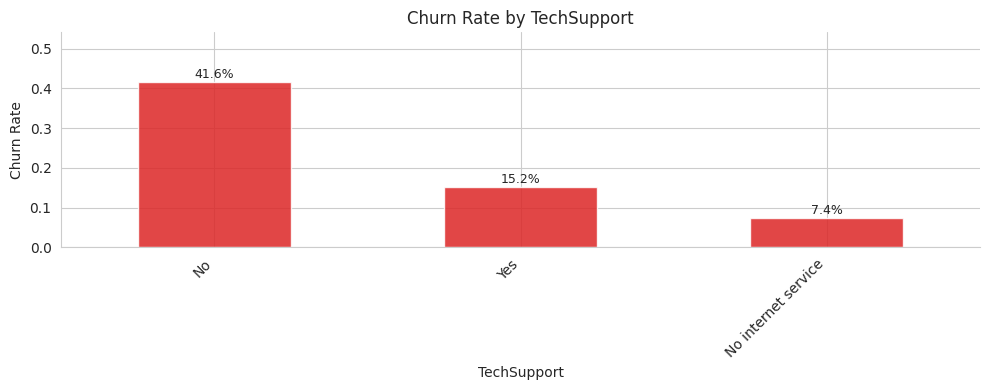

In [11]:
plot_churn_rate_by_feature(df, 'TechSupport')

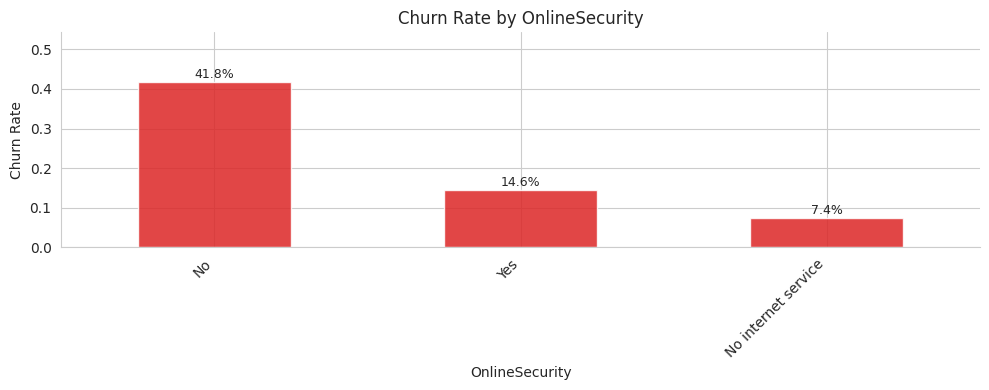

In [12]:
plot_churn_rate_by_feature(df, 'OnlineSecurity')

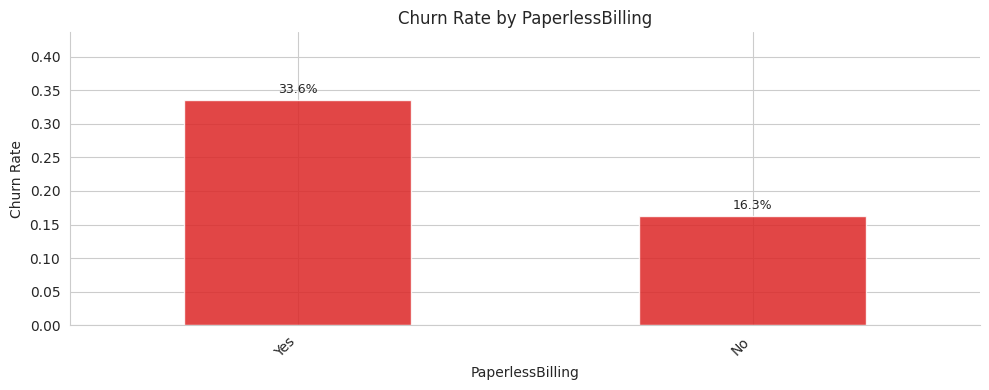

In [13]:
plot_churn_rate_by_feature(df, 'PaperlessBilling')

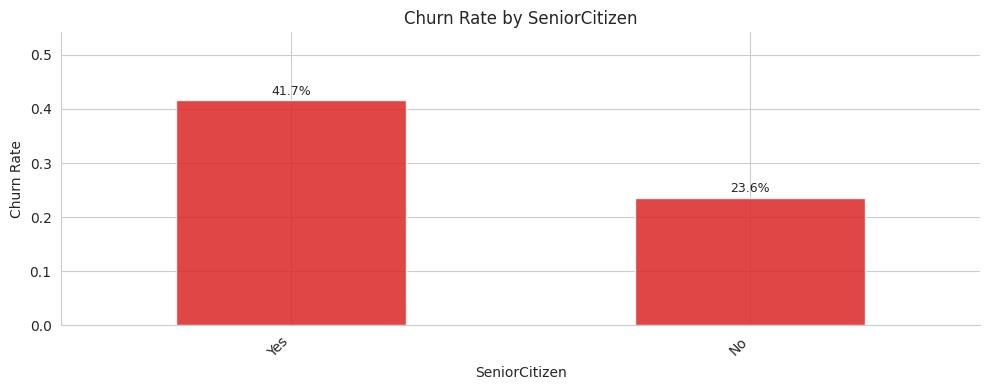

In [14]:
plot_churn_rate_by_feature(df, 'SeniorCitizen')

### Key Observations

1. **Contract type** is the strongest signal: month-to-month customers churn at ~42%, compared to ~11% for one-year and ~3% for two-year contracts. Shorter contracts mean lower switching costs.

2. **Fiber optic internet** customers churn more than DSL or no-internet customers. This could be a price effect (fiber is more expensive) or a service quality issue.

3. **No tech support / no online security** strongly correlates with higher churn. Customers without protective services are less "sticky."

4. **Electronic check payment** has the highest churn rate among payment methods.

5. **Paperless billing** customers churn slightly more -- possibly correlated with digital-native users who comparison-shop more actively.

## 4. Tenure Distribution by Churn

New customers are expected to churn disproportionately -- a finding with direct business implications for onboarding programs.

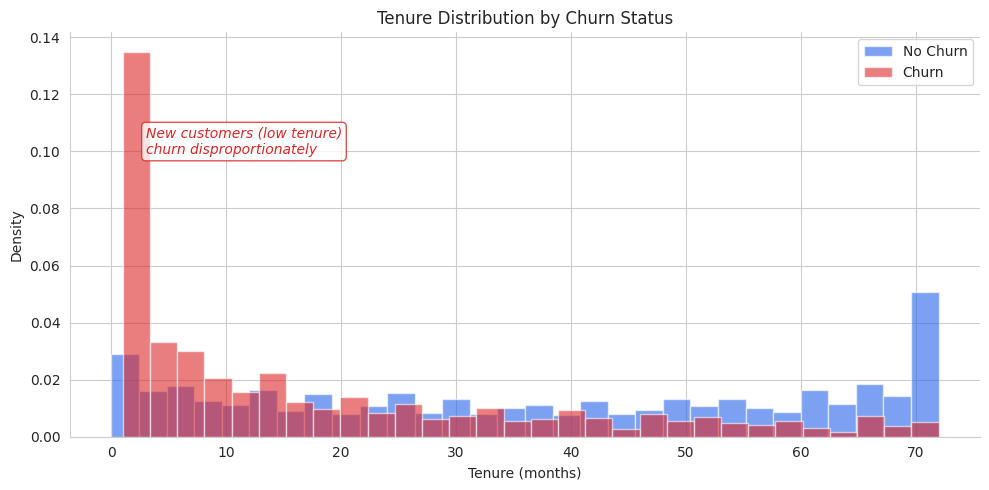

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

ax.hist(retained, bins=30, alpha=0.6, color=COLORS['no_churn'],
        label='No Churn', density=True, edgecolor='white')
ax.hist(churned, bins=30, alpha=0.6, color=COLORS['churn'],
        label='Churn', density=True, edgecolor='white')

ax.set_title('Tenure Distribution by Churn Status')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Density')
ax.legend()
ax.annotate('New customers (low tenure)\nchurn disproportionately',
            xy=(3, ax.get_ylim()[1] * 0.7), fontsize=10, style='italic',
            color=COLORS['churn'],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=COLORS['churn'], alpha=0.8))
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/566071142.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby(feature)['Churn'].apply(


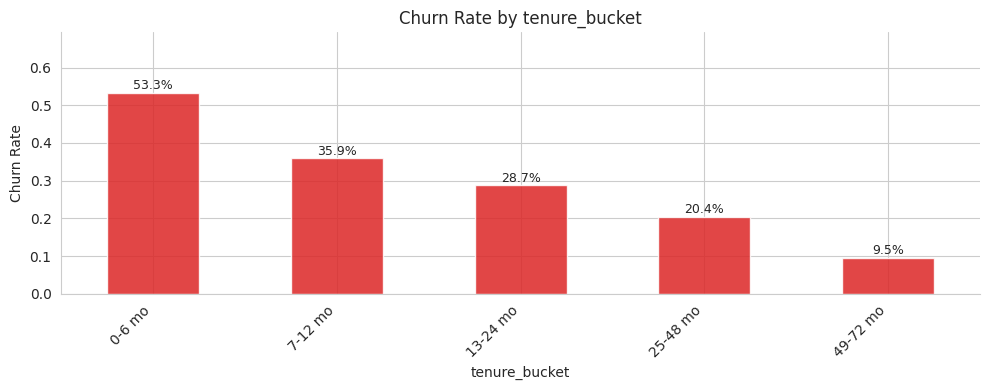

In [16]:
# Churn rate by tenure buckets
df_temp = df.copy()
df_temp['tenure_bucket'] = pd.cut(
    df_temp['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']
)
plot_churn_rate_by_feature(df_temp, 'tenure_bucket')

**Insight**: Customers in their first 6 months are the highest churn risk. A targeted onboarding/engagement program for this cohort could have the highest ROI.

## 5. Numeric Feature Distributions

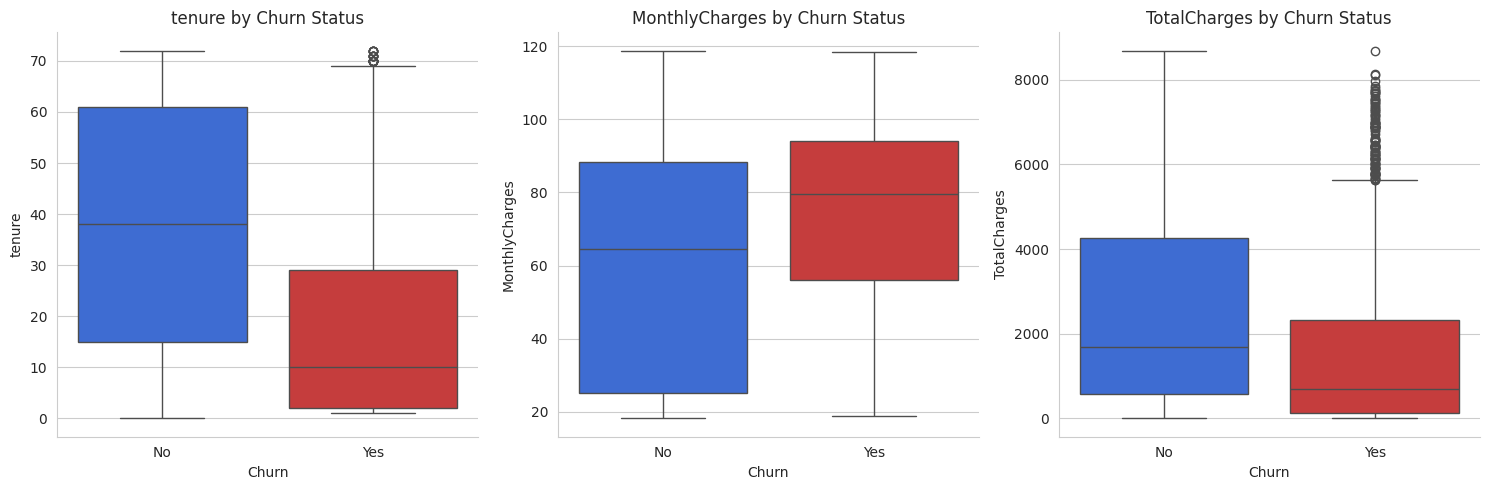

In [17]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax,
                palette=[COLORS['no_churn'], COLORS['churn']],
                hue='Churn', legend=False)
    ax.set_title(f'{col} by Churn Status')

plt.tight_layout()
plt.show()

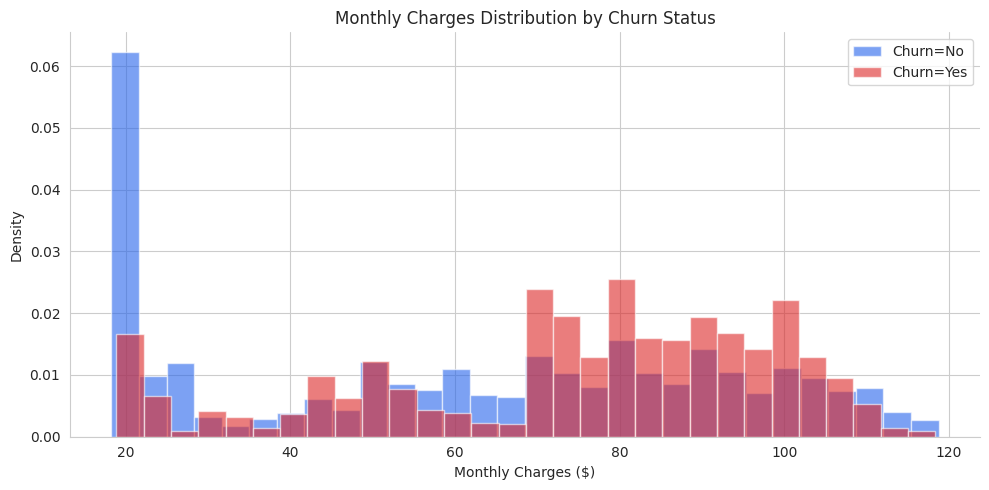

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [('No', '#2563eb'), ('Yes', '#dc2626')]:
    subset = df[df['Churn'] == label]['MonthlyCharges']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=f'Churn={label}', density=True, edgecolor='white')
ax.set_title('Monthly Charges Distribution by Churn Status')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

**Insight**: Churned customers tend to have higher monthly charges. This could indicate price sensitivity, or it could be confounded by fiber optic (more expensive) having higher churn.

## 6. Correlation Analysis

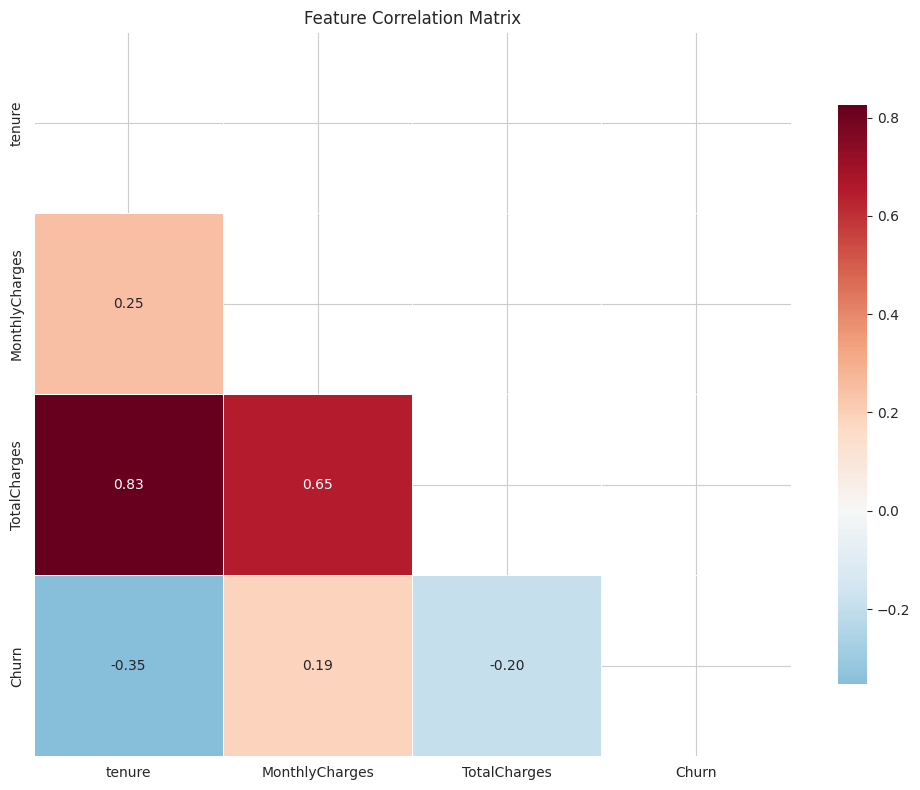

In [19]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})
numeric_df = df_corr.select_dtypes(include=['number'])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Multi-feature Interaction: The Highest-Risk Segment

Combining the top churn drivers to identify the most at-risk customer segment.

In [20]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['TechSupport'] == 'No') &
    (df['tenure'] < 12)
]

overall_churn = (df['Churn'] == 'Yes').mean()
segment_churn = (high_risk['Churn'] == 'Yes').mean()

print(f'Overall churn rate: {overall_churn:.1%}')
print(f'High-risk segment churn rate: {segment_churn:.1%}')
print(f'Lift: {segment_churn / overall_churn:.1f}x')
print(f'Segment size: {len(high_risk)} customers ({len(high_risk)/len(df):.1%} of total)')

Overall churn rate: 26.5%
High-risk segment churn rate: 61.7%
Lift: 2.3x
Segment size: 1313 customers (18.6% of total)


## 8. Summary of Findings

### Data Quality
- `TotalCharges` blank strings for 11 zero-tenure customers -- handled by converting to 0.0
- No other missing values
- Class imbalance: 73/27 split (meaningful but not extreme)

### Top Churn Drivers (for feature engineering)
1. **Contract type** -- month-to-month is the strongest churn predictor
2. **Tenure** -- new customers (< 12 months) churn disproportionately
3. **Tech support / Online security** -- absence correlates with higher churn
4. **Monthly charges** -- higher charges associated with more churn
5. **Internet service type** -- fiber optic has highest churn
6. **Payment method** -- electronic check stands out

### Business Insight
Month-to-month contract customers with no tech support and under 12 months tenure are the highest-risk segment. A retention offer targeting exactly this group would be more efficient than a blanket discount.